# WEB SCRAPING

In [14]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

In [ ]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

data = []

for limit in range(0, 7000, 25):
    url = f"http://www.world-art.ru/animation/list.php?limit_1={limit}"
    print(f"Парсим страницу: {url}")

    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.encoding = 'windows-1251'
        soup = BeautifulSoup(response.text, "html.parser")

        rows = soup.find_all("tr")
        page_count = 0 # Счётчик аниме на конкретной странице

        for row in rows:
            review_td = row.find("td", class_="review")
            if not review_td:
                continue

            title_tag = review_td.find("a", class_="h3")
            if not title_tag:
                continue

            title = title_tag.get_text(strip=True)
            link = "http://www.world-art.ru/animation/" + title_tag["href"]


            full_text = review_td.get_text("\n", strip=True)
            row_text = row.get_text("|", strip=True)


            rating_match = re.search(r"(\d+\.\d+)\|средний балл", row_text)
            rating = rating_match.group(1) if rating_match else None

            def extract_field(pattern, text):
                match = re.search(pattern, text, re.IGNORECASE)
                return match.group(1).strip() if match else None

            genres = extract_field(r"Жанры:\s*(.*)", full_text)
            origin = extract_field(r"В основе лежит\s*(.*)", full_text)
            release_date = extract_field(r"Первый релиз:\s*(\d{2}\.\d{2}\.\d{4})", full_text)
            authors = extract_field(r"В ролях:\s*(.*)", full_text)

            ep_match = re.search(r"(\d+)\s*эп", full_text)
            dur_match = re.search(r"(\d+)\s*мин", full_text)
            episodes = ep_match.group(1) if ep_match else "1"
            duration = dur_match.group(1) if dur_match else None

            description = None
            if "Синопсис:" in full_text:
                description = full_text.split("Синопсис:")[-1].replace("есть описание", "").strip()

            data.append({
                "Название": title,
                "Рейтинг": rating,
                "Кол-во серий": episodes,
                "Длительность (мин)": duration,
                "Жанры": genres,
                "Дата релиза": release_date,
                "Тип оригинала": origin,
                "Авторы": authors,
                "Описание": description,
                "Ссылка": link
            })
            page_count += 1

        print(f"Успешно собрано {page_count} аниме с этой страницы. Всего в базе: {len(data)}")


        time.sleep(1.5)

    except Exception as e:
        print(f"Ошибка на лимите {limit}: {e}")
        continue

е
df = pd.DataFrame(data)
df.to_csv("world_art_5000_rows.csv", index=False, encoding="utf-8-sig")
print("\n--- СБОР ЗАВЕРШЕН ---")
print(f"Итого собрано строк: {len(df)}")

#Data Cleaning

## Handle missing values

In [18]:
from google.colab import files
uploaded = files.upload()

Saving world_art_5000_rows.csv to world_art_5000_rows.csv


In [20]:
df = pd.read_csv("world_art_5000_rows.csv")

In [21]:
df

,Название,Рейтинг,Кол-во серий,Длительность (мин),Жанры,Дата релиза,Тип оригинала,Авторы,Описание,Ссылка
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",30.06.1999,манга,Такаги Ватару,"Эйкити Онидзука\n(«22 года, холост», - как он ...",http://www.world-art.ru/animation/animation.ph...
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",06.04.2008,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",05.04.2009,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",20.07.2001,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",06.04.2011,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...
...,...,...,...,...,...,...,...,...,...,...
5820,Gensou Jotan Ellcia,6.9,4,50.0,"приключения, фэнтези",23.10.1992,оригинальная идея,Икура Кадзуэ,Техно-фентези. Одна страна нашла древние техно...,http://www.world-art.ru/animation/animation.ph...
5821,Exper Zenon,6.9,1,60.0,"приключения, фантастика",27.09.1991,оригинальная идея,Мацуно Тайки,"описания ещё нет\nВ ролях:\nМацуно Тайки\n,\nТ...",http://www.world-art.ru/animation/animation.ph...
5822,Дайбастер: Дотянись до неба - 2 (фильм),6.8,1,100.0,"приключения, комедия, фантастика, меха",01.10.2006,оригинальная идея,NaN,описания ещё нет,http://www.world-art.ru/animation/animation.ph...
5823,Принцесса Минерва,6.8,1,45.0,"приключения, комедия, фэнтези",01.05.1995,видеоигра,Ито Мики,"описания ещё нет\nВ ролях:\nИто Мики\n,\nИноэ ...",http://www.world-art.ru/animation/animation.ph...


In [22]:
df.isna().sum()

,0
Название,0
Рейтинг,98
Кол-во серий,0
Длительность (мин),38
Жанры,22
Дата релиза,98
Тип оригинала,799
Авторы,1665
Описание,0
Ссылка,0


In [23]:
df.rename(columns = {'Длительность (мин)':'Duration_time', "Рейтинг":"Rating","Название":"Name","Кол-во серий":"Number_Episodes","Жанры":"Genres",'Дата релиза':'Release_date','Тип оригинала':"Original_type","Авторы":"Authors","Описание":"Description","Ссылка":"Link"}, inplace = True)

In [24]:
# Drop rows where Rating and Release_date none
df = df.dropna(subset =["Rating","Release_date"])

In [25]:
# Refill rows duration time and genres with their mode values
df["Duration_time"] = df["Duration_time"].fillna(df["Duration_time"].mode()[0])
df["Genres"] = df["Genres"].fillna(df["Genres"].mode()[0])

/tmp/ipykernel_7344/3500601296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Duration_time"] = df["Duration_time"].fillna(df["Duration_time"].mode()[0])
/tmp/ipykernel_7344/3500601296.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Genres"] = df["Genres"].fillna(df["Genres"].mode()[0])


In [26]:
# Refill none rows Original_type and Authors by unknown
df["Original_type"] = df["Original_type"].fillna("Unknown")
df["Authors"] = df["Authors"].fillna("Unknown")

/tmp/ipykernel_7344/3205480759.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Original_type"] = df["Original_type"].fillna("Unknown")
/tmp/ipykernel_7344/3205480759.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Authors"] = df["Authors"].fillna("Unknown")


In [27]:
df.isna().sum()

,0
Name,0
Rating,0
Number_Episodes,0
Duration_time,0
Genres,0
Release_date,0
Original_type,0
Authors,0
Description,0
Link,0


In [28]:
df.duplicated().sum()

np.int64(0)

## Standardize data type

In [29]:
df.dtypes

,0
Name,object
Rating,float64
Number_Episodes,int64
Duration_time,float64
Genres,object
Release_date,object
Original_type,object
Authors,object
Description,object
Link,object


In [30]:
df["Release_date"] = pd.to_datetime(df["Release_date"])
df["Genres"] = df["Genres"].astype("string")
df["Original_type"] = df["Original_type"].astype("string")
df["Authors"] = df["Authors"].astype("string")

/tmp/ipykernel_7344/2768975433.py:1: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Release_date"] = pd.to_datetime(df["Release_date"])
/tmp/ipykernel_7344/2768975433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Release_date"] = pd.to_datetime(df["Release_date"])
/tmp/ipykernel_7344/2768975433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Genres"] = df["Genres"].astype

In [31]:
df.dtypes

,0
Name,object
Rating,float64
Number_Episodes,int64
Duration_time,float64
Genres,string[python]
Release_date,datetime64[ns]
Original_type,string[python]
Authors,string[python]
Description,object
Link,object


## Detect and handle outliers


In [32]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Z-score
z_sc = np.abs(stats.zscore(df.select_dtypes(include=np.number)))

#z-score > 3
outliner_indices = np.where(z_sc > 3)
print(f"Number of outliers: {len(outliner_indices[0])}")

Number of outliers: 186


1)In column "Rating" values can lie in range between 0 and 10, as we see here no outliers which doesnt exist above value "10"


2)In column "Number_Episodes" range can accept any positive number, which also say us quantity of episodes might be more than a few thousands

3)In column "Duration_time" also doesnt exist any oultliers. Values given us as a minutes and they are represents existing big movies

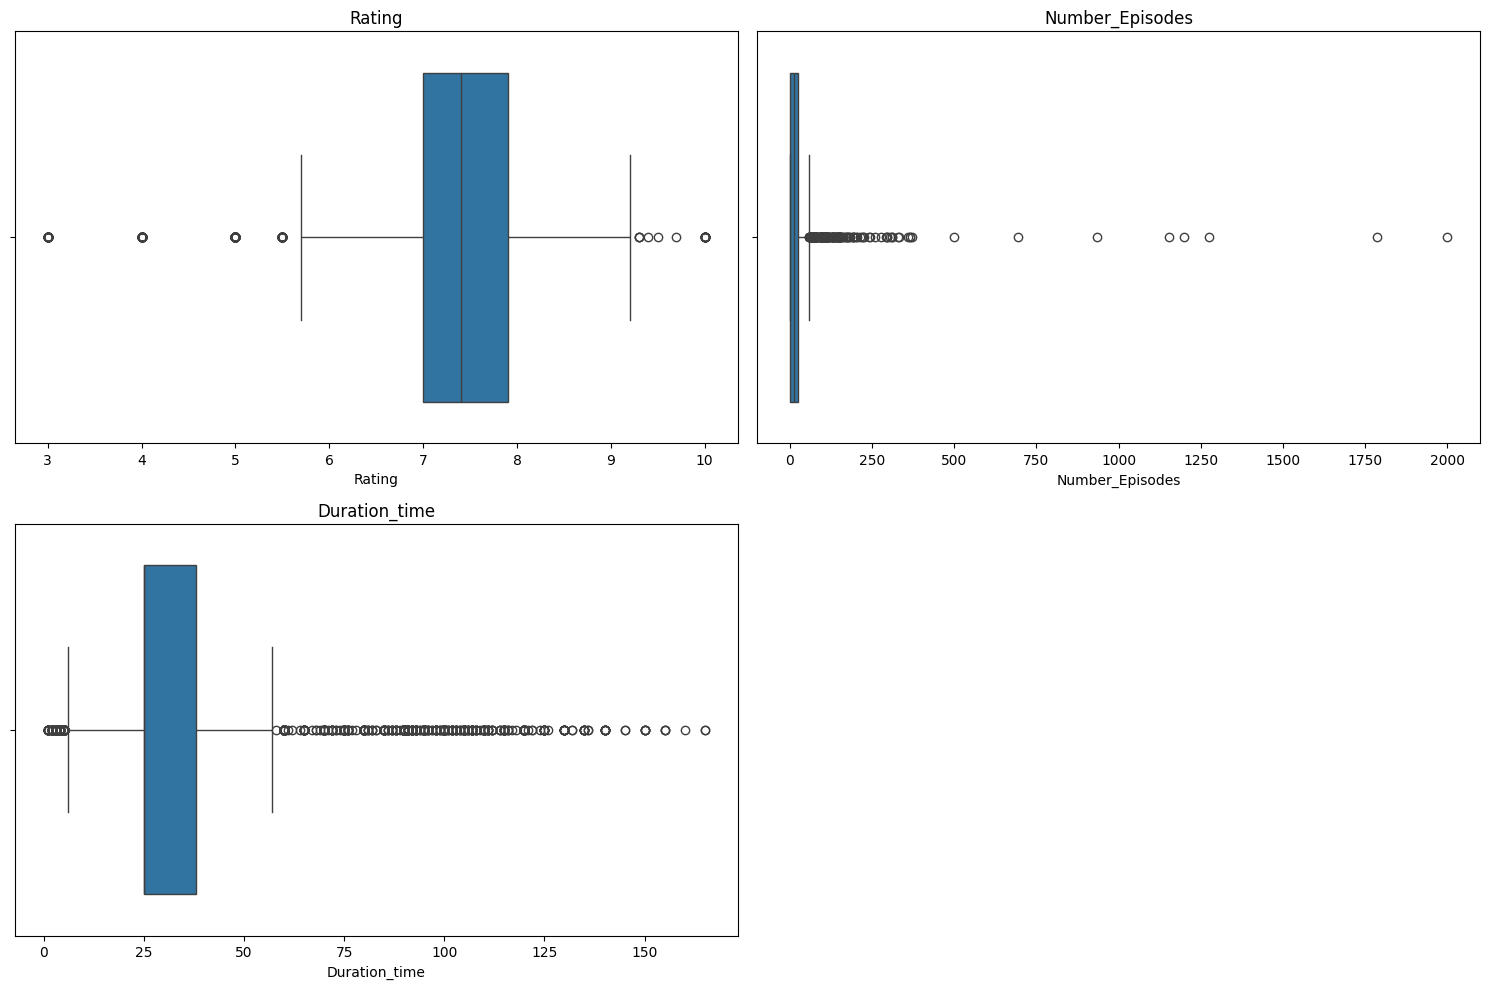

In [36]:
num_col = df.select_dtypes(include=["number"]).columns
num_plots = len(num_col)

plt.figure(figsize=(15, 5 * ((num_plots + 1) // 2)))
for i, col in enumerate(num_col, 1):
    plt.subplot((num_plots + 1) //2 ,2,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [37]:
df = df.reset_index(drop=True)
df

,Name,Rating,Number_Episodes,Duration_time,Genres,Release_date,Original_type,Authors,Description,Link
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",1999-06-30,манга,Такаги Ватару,"Эйкити Онидзука\n(«22 года, холост», - как он ...",http://www.world-art.ru/animation/animation.ph...
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",2008-04-06,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",2009-04-05,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",2001-07-20,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",2011-04-06,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...
...,...,...,...,...,...,...,...,...,...,...
5624,Gensou Jotan Ellcia,6.9,4,50.0,"приключения, фэнтези",1992-10-23,оригинальная идея,Икура Кадзуэ,Техно-фентези. Одна страна нашла древние техно...,http://www.world-art.ru/animation/animation.ph...
5625,Exper Zenon,6.9,1,60.0,"приключения, фантастика",1991-09-27,оригинальная идея,Мацуно Тайки,"описания ещё нет\nВ ролях:\nМацуно Тайки\n,\nТ...",http://www.world-art.ru/animation/animation.ph...
5626,Дайбастер: Дотянись до неба - 2 (фильм),6.8,1,100.0,"приключения, комедия, фантастика, меха",2006-10-01,оригинальная идея,Unknown,описания ещё нет,http://www.world-art.ru/animation/animation.ph...
5627,Принцесса Минерва,6.8,1,45.0,"приключения, комедия, фэнтези",1995-05-01,видеоигра,Ито Мики,"описания ещё нет\nВ ролях:\nИто Мики\n,\nИноэ ...",http://www.world-art.ru/animation/animation.ph...


## Perform feature engineering

Here we've added bins which dividing data by categeries

1) Data in Column "Rating" was changed by quality. Values between [1-5 = "low"], [5-8,5 = "good"],[8,5-10 = "exellent"] has categories yet


 2. Column "Movie_Serial" was categorized based on the number of episodes. Titles with 1 episode are labeled as "Movie," while those with more are classified as "Serial."

 3. Column "Decade" was created by extracting the year from "Release_date" and grouping it into 10-year intervals (bins) to identify the era of the anime, from the "80s" to the "20s."

 4. Column "Duration_hour" simplifies the exact running time into three categories: "less than hour," "more than hour," and "more than 2 hours" for easier time-based filtering.

In [38]:
df['Quality_rating'] = pd.cut(df["Rating"],
                              bins = [1,5,8.5,10],
                              labels = ["low","Good","Excellent"])
df["Movie_Serial"] = pd.cut(df["Number_Episodes"],
                            bins = [0,1,3000],
                            labels = ["Movie","Serial"])
df["Decade"] = pd.cut(df["Release_date"].dt.year,
                      bins =[1980,1990,2000,2010,2020,2030],
                      labels = ["80's","90's","00's","10's","20's"])
df["Duration_hour"] = pd.cut(df["Duration_time"],
                             bins = [0,60,120,180],
                             labels = ["less than hour","more than hour","more than 2 hours"])
df

,Name,Rating,Number_Episodes,Duration_time,Genres,Release_date,Original_type,Authors,Description,Link,Quality_rating,Movie_Serial,Decade,Duration_hour
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",1999-06-30,манга,Такаги Ватару,"Эйкити Онидзука\n(«22 года, холост», - как он ...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,90's,less than hour
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",2008-04-06,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",2009-04-05,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",2001-07-20,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Movie,00's,more than 2 hours
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",2011-04-06,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,10's,less than hour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5624,Gensou Jotan Ellcia,6.9,4,50.0,"приключения, фэнтези",1992-10-23,оригинальная идея,Икура Кадзуэ,Техно-фентези. Одна страна нашла древние техно...,http://www.world-art.ru/animation/animation.ph...,Good,Serial,90's,less than hour
5625,Exper Zenon,6.9,1,60.0,"приключения, фантастика",1991-09-27,оригинальная идея,Мацуно Тайки,"описания ещё нет\nВ ролях:\nМацуно Тайки\n,\nТ...",http://www.world-art.ru/animation/animation.ph...,Good,Movie,90's,less than hour
5626,Дайбастер: Дотянись до неба - 2 (фильм),6.8,1,100.0,"приключения, комедия, фантастика, меха",2006-10-01,оригинальная идея,Unknown,описания ещё нет,http://www.world-art.ru/animation/animation.ph...,Good,Movie,00's,more than hour
5627,Принцесса Минерва,6.8,1,45.0,"приключения, комедия, фэнтези",1995-05-01,видеоигра,Ито Мики,"описания ещё нет\nВ ролях:\nИто Мики\n,\nИноэ ...",http://www.world-art.ru/animation/animation.ph...,Good,Movie,90's,less than hour


## TEXT NORMALIZATION

1. Removing literal newline escape sequences ('\n') introduced during data extraction.
2. Standardizing the "In roles:" (В ролях) prefix for consistency.
3. Collapsing multiple spaces and stripping leading/trailing whitespace.
4. Handling potential non-string values to ensure the script doesn't crash.

In [39]:
def normalize_text(text):
    if not isinstance(text, str):
        return text
    text = text.replace(r'\n', ' ')
    text = text.replace('ролях:', 'В ролях: ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
df['Description'] = df['Description'].apply(normalize_text)
df.head(15)

,Name,Rating,Number_Episodes,Duration_time,Genres,Release_date,Original_type,Authors,Description,Link,Quality_rating,Movie_Serial,Decade,Duration_hour
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",1999-06-30,манга,Такаги Ватару,"Эйкити Онидзука («22 года, холост», - как он с...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,90's,less than hour
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",2008-04-06,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",2009-04-05,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",2001-07-20,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Movie,00's,more than 2 hours
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",2011-04-06,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,10's,less than hour
5,Кланнад [ТВ-2],9.1,22,25.0,"романтика, драма, повседневность",2008-10-03,видеоигра,Накамура Юйти,"Сериал берет новый старт там, где окончился пе...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
6,Бек,9.0,26,25.0,"комедия, повседневность, музыкальный",2004-10-07,манга,Намикава Дайсукэ,"В начале была Песня – так верят многие народы,...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
7,Брошенный кролик,9.0,11,25.0,"комедия, драма, повседневность",2011-07-08,манга,Цутида Хироси,"30-летний Дайкити Кавати, холостяк и работогол...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,10's,less than hour
8,Тетрадь смерти [ТВ],9.0,37,25.0,"мистика, триллер, детектив",2006-10-04,манга,Мияно Мамору,У старшеклассника Лайта Ягами в жизни есть всё...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,00's,less than hour
9,Твоё имя,9.0,1,110.0,"романтика, драма",2016-07-03,оригинальная идея,Камики Рюносукэ,В размеренном спокойствии проходит её жизнь в ...,http://www.world-art.ru/animation/animation.ph...,Excellent,Movie,10's,more than hour


In [40]:
df.loc[10,"Authors"] = df["Authors"].str.split(",")[0]

In [41]:
df.to_csv("world_art_5000_rows_cleaned.csv", index=False)

# **Exploratory Data Analysis**

**Descriptive Statistics**

In [42]:
import pandas as pd
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

desc_stats = df[num_cols].describe().T

modes = df[num_cols].mode().iloc[0].rename("mode")
final_stats = desc_stats.join(modes)

columns_to_show = ['mean', '50%', 'mode', 'std', '25%', '75%']
final_stats = final_stats[columns_to_show].rename(columns={
    '50%': 'median',
    '25%': 'Q1 (25%)',
    '75%': 'Q3 (75%)'
})

display(final_stats.round(2))

,mean,median,mode,std,Q1 (25%),Q3 (75%)
Rating,7.37,7.4,7.0,0.90,7.0,7.9
Number_Episodes,17.85,12.0,1.0,55.12,1.0,24.0
Duration_time,37.22,25.0,25.0,28.96,25.0,38.0


**Distribution Analysis**

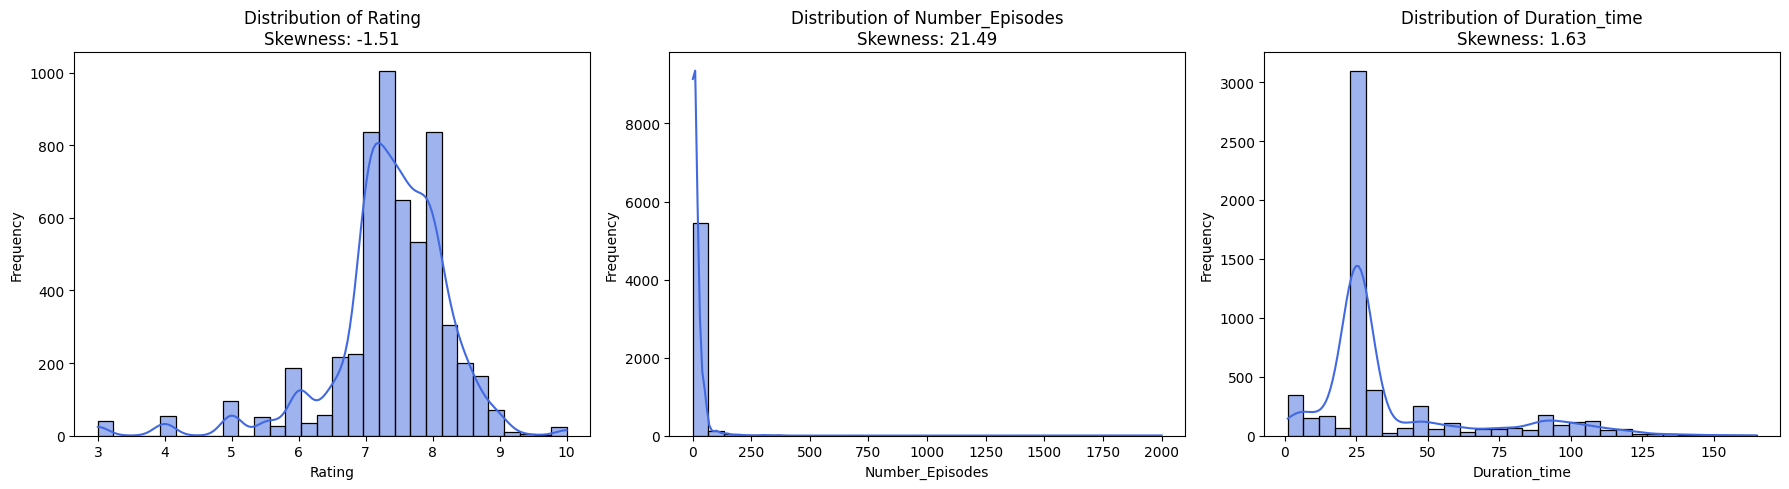

--- Skewness Values ---
Rating             -1.51
Number_Episodes    21.49
Duration_time       1.63
dtype: float64


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    skewness = df[col].skew()
    sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', bins=30)

    axes[i].set_title(f'Distribution of {col}\nSkewness: {skewness:.2f}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.show()
print("--- Skewness Values ---")
print(df[num_cols].skew().round(2))

**Correlation Analysis**

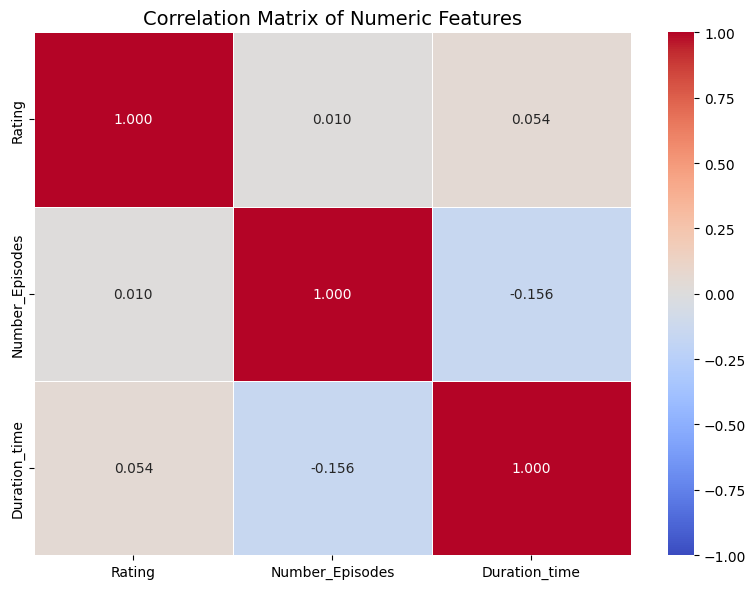

--- Correlation Matrix ---


,Rating,Number_Episodes,Duration_time
Rating,1.000,0.010,0.054
Number_Episodes,0.010,1.000,-0.156
Duration_time,0.054,-0.156,1.000


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

print("--- Correlation Matrix ---")
display(corr_matrix.round(3))

**Group-by Analysis**

--- Average Metrics by Original Source ---


,Rating,Number_Episodes
Original_type,,
ранобэ,7.63,11.10
манга,7.50,19.91
книга,7.46,14.17
видеоигра,7.34,15.55
оригинальная идея,7.31,18.20
Unknown,6.86,16.78
мобильная игра,6.71,16.46


/tmp/ipykernel_7344/2802336799.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groupby_stats.index, y=groupby_stats['Rating'], palette='viridis')


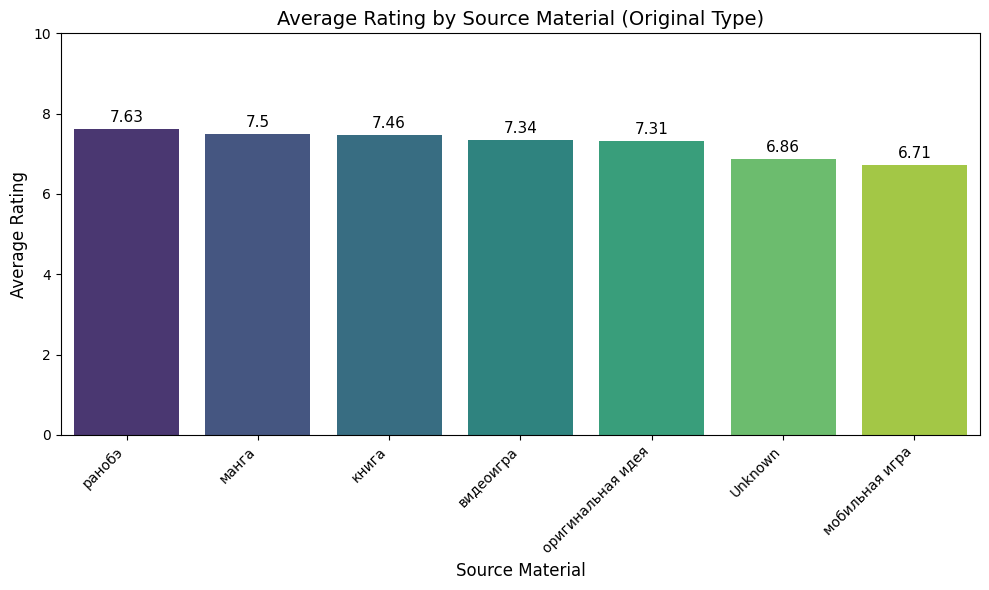

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

top_types = df['Original_type'].value_counts().nlargest(7).index
df_top_types = df[df['Original_type'].isin(top_types)]

groupby_stats = df_top_types.groupby('Original_type')[['Rating', 'Number_Episodes']].mean().round(2)

groupby_stats = groupby_stats.sort_values(by='Rating', ascending=False)

print("--- Average Metrics by Original Source ---")
display(groupby_stats)

plt.figure(figsize=(10, 6))
sns.barplot(x=groupby_stats.index, y=groupby_stats['Rating'], palette='viridis')

for index, value in enumerate(groupby_stats['Rating']):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=11)
plt.title('Average Rating by Source Material (Original Type)', fontsize=14)
plt.xlabel('Source Material', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(0, 10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Top-N and Bottom-N Analysis**

In [46]:
import pandas as pd

columns_to_show = ['Name', 'Rating', 'Genres', 'Original_type', 'Number_Episodes']

top_5_anime = df.nlargest(5, 'Rating')[columns_to_show]

bottom_5_anime = df.nsmallest(5, 'Rating')[columns_to_show]

print("--- TOP 5 Highest-Rated Anime ---")
display(top_5_anime)

print("\n--- BOTTOM 5 Lowest-Rated Anime ---")
display(bottom_5_anime)

--- TOP 5 Highest-Rated Anime ---


,Name,Rating,Genres,Original_type,Number_Episodes
2127,Hula Kapper,10.0,"комедия, повседневность",оригинальная идея,78
2128,Genki Bakuhatsu Ganbaruger,10.0,"приключения, фантастика, меха",оригинальная идея,47
2624,Saikyou Kamizmode!,10.0,приключения,оригинальная идея,52
2625,Tamagotchi! Tama Tomo Daishuu Go,10.0,приключения,видеоигра,26
2626,Chou Zenmairobo: Patrasche,10.0,комедия,оригинальная идея,13



--- BOTTOM 5 Lowest-Rated Anime ---


,Name,Rating,Genres,Original_type,Number_Episodes
5258,Эльф из Канагавы,3.0,"повседневность, фэнтези",манга,12
5259,Поэзия теней: Арк,3.0,приключения,оригинальная идея,23
5260,Rock'n Oyone,3.0,приключения,оригинальная идея,1
5261,Chickip Dancers,3.0,приключения,Unknown,26
5262,Oshiete Hokusai! The Animation,3.0,приключения,манга,10


**Hypotheses Testing**

**Hypothesis 1** (Anime with a larger number of episodes have a higher rating.)

In [47]:
corr_ep = df[["Rating","Number_Episodes"]].corr()
corr_ep

,Rating,Number_Episodes
Rating,1.000000,0.009788
Number_Episodes,0.009788,1.000000


The correlation between the number of episodes and the rating is weak (close to 0). This means that the number of episodes has practically no effect on the anime's rating. The hypothesis is not confirmed.

**Hypothesis 2** (Anime with longer episodes have higher ratings.)

In [48]:
corr_dur = df[["Rating","Duration_time"]].corr()
corr_dur

,Rating,Duration_time
Rating,1.000000,0.054131
Duration_time,0.054131,1.000000


The connection between episode duration and rating is very weak or zero. This means that episode length doesn't really affect the score. The hypothesis is not confirmed.

**Hypothesis 3** (The source material affects the anime rating.)

In [49]:
rating_by_type = df.groupby("Original_type")["Rating"].mean().sort_values(ascending=False)
rating_by_type

,Rating
Original_type,
пьеса,8.000000
фильм,7.830000
ранобэ,7.626357
комикс,7.600000
манга,7.500931
книга,7.461631
видеоигра,7.342140
оригинальная идея,7.314815
Unknown,6.864374


The average rating differs depending on the source material. Some types (like manga) get higher scores. This shows a connection between the source type and the rating. The hypothesis is confirmed.

**Time-Based Analysis**

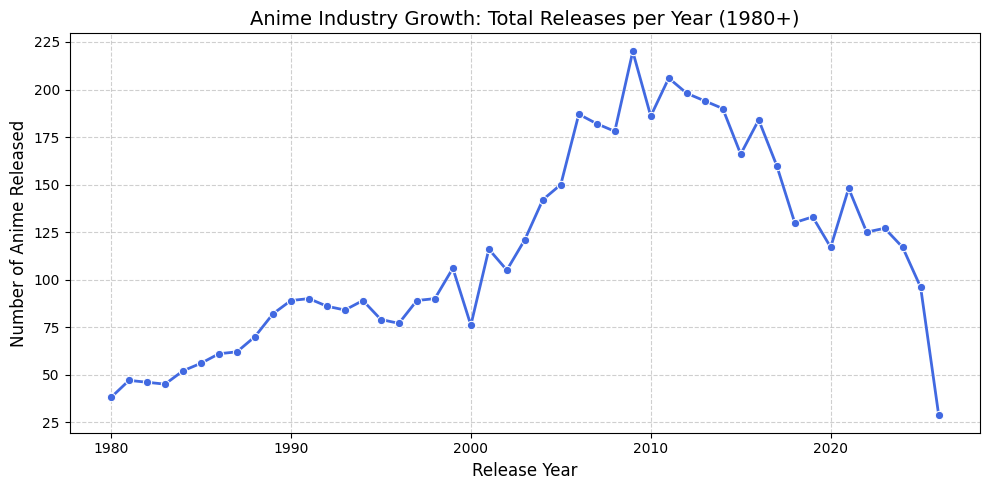

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'Release_Year' not in df.columns:
    df['Release_Year'] = df['Release_date'].dt.year

yearly_counts = df.groupby('Release_Year')['Name'].count().reset_index()
yearly_counts.rename(columns={'Name': 'Total_Releases'}, inplace=True)

yearly_counts = yearly_counts[yearly_counts['Release_Year'] >= 1980]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_counts, x='Release_Year', y='Total_Releases', marker='o', color='royalblue', linewidth=2)

plt.title('Anime Industry Growth: Total Releases per Year (1980+)', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Anime Released', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Data Vizualization

In [51]:
# Загружаем датасет из CSV-файла:
import pandas as pd
df = pd.read_csv("world_art_5000_rows.csv", encoding='utf-8-sig', engine='python', on_bad_lines='warn')

In [52]:
display(df.head())

,Название,Рейтинг,Кол-во серий,Длительность (мин),Жанры,Дата релиза,Тип оригинала,Авторы,Описание,Ссылка
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",30.06.1999,манга,Такаги Ватару,"Эйкити Онидзука\n(«22 года, холост», - как он ...",http://www.world-art.ru/animation/animation.ph...
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",06.04.2008,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",05.04.2009,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",20.07.2001,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",06.04.2011,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...


In [53]:
# Install a font supporting Cyrillic characters
!sudo apt-get install -y fonts-dejavu-extra

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core
The following NEW packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,082 kB of archives.
After this operation, 10.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Fetched 3,082 kB in 2s (1,983 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend require

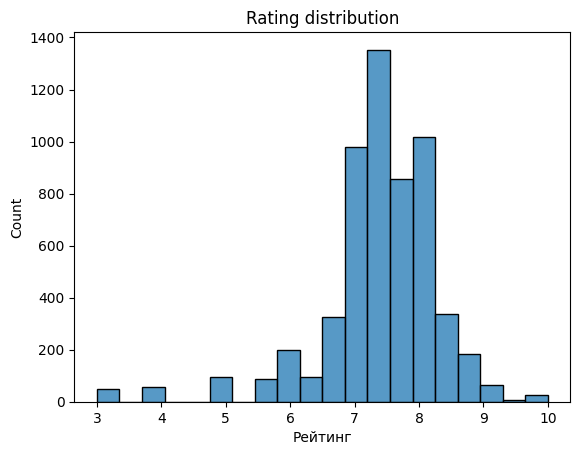

In [54]:
# Plot a histogram to visualize the distribution of ratings:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Рейтинг'], bins=20)
plt.title("Rating distribution")
plt.show()

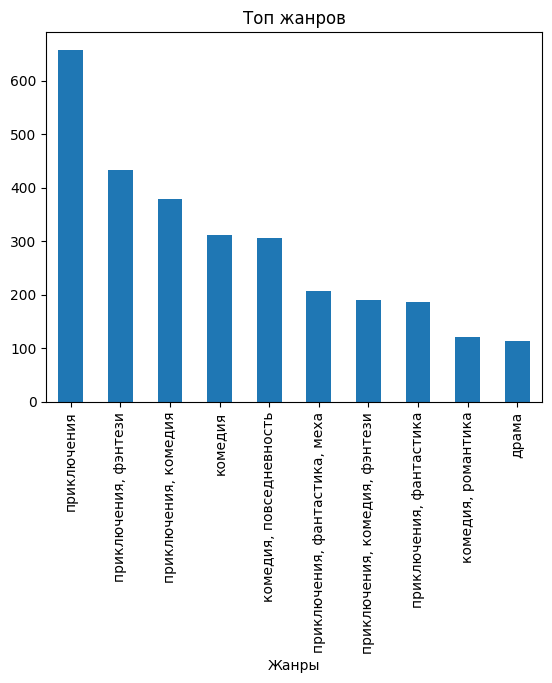

In [55]:
# Create a bar chart of the top 10 most frequent genres:
df['Жанры'].value_counts().head(10).plot(kind='bar')
plt.title("Топ жанров")
plt.show()

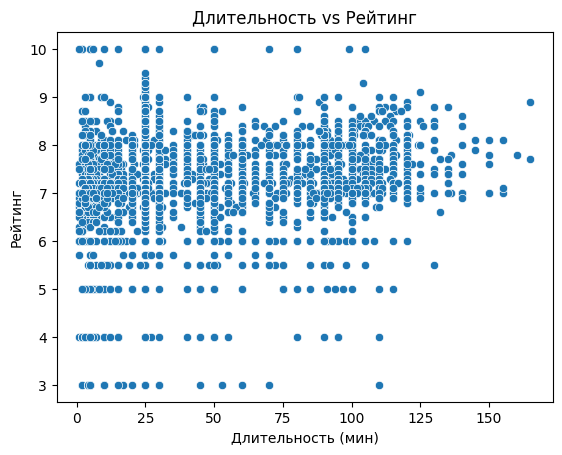

In [56]:
# Create a scatter plot to analyze the relationship between duration and rating
sns.scatterplot(x='Длительность (мин)', y='Рейтинг', data=df)
plt.title("Длительность vs Рейтинг")
plt.show()

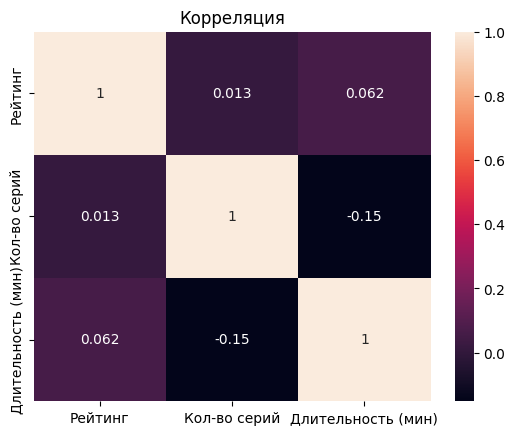

In [57]:
# Compute and visualize the correlation matrix
corr = df[['Рейтинг', 'Кол-во серий', 'Длительность (мин)']].corr()
sns.heatmap(corr, annot=True)
plt.title("Корреляция")
plt.show()

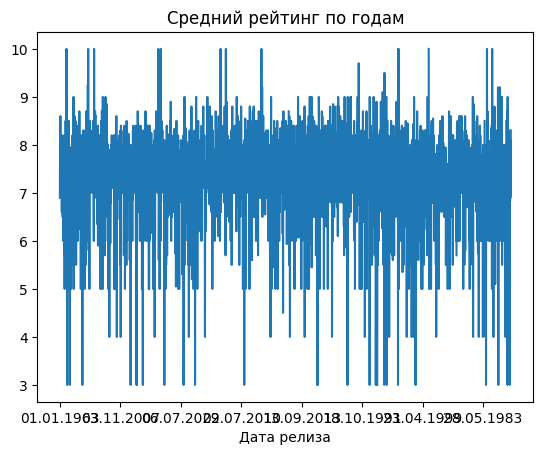

In [58]:
# Analyze rating trends over time
df.groupby('Дата релиза')['Рейтинг'].mean().plot()
plt.title("Средний рейтинг по годам")
plt.show()

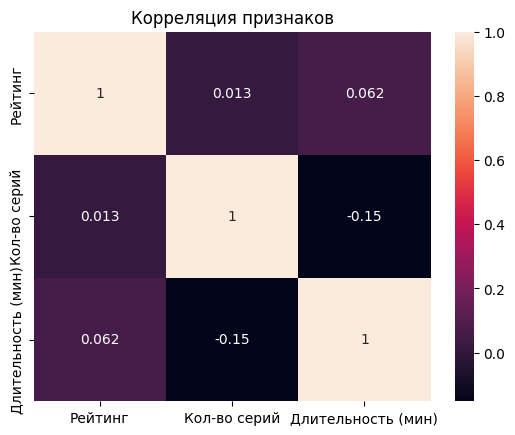

In [59]:
# Heatmap showing correlation between Rating, Number of Episodes, and Duration
plt.figure()
corr = df[['Рейтинг', 'Кол-во серий', 'Длительность (мин)']].corr()
sns.heatmap(corr, annot=True)
plt.title("Корреляция признаков")
plt.show()

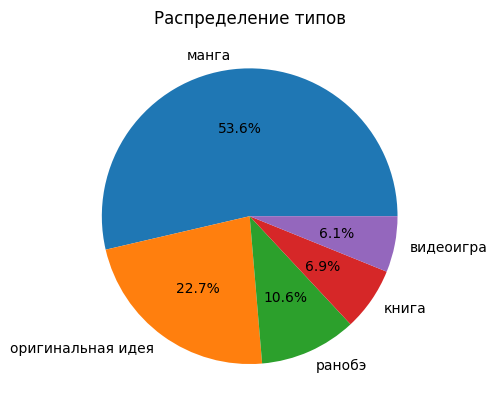

In [60]:
# Pie chart showing the distribution of top 5 original content types
plt.figure()
df['Тип оригинала'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%')
plt.title("Распределение типов")
plt.ylabel("")
plt.show()

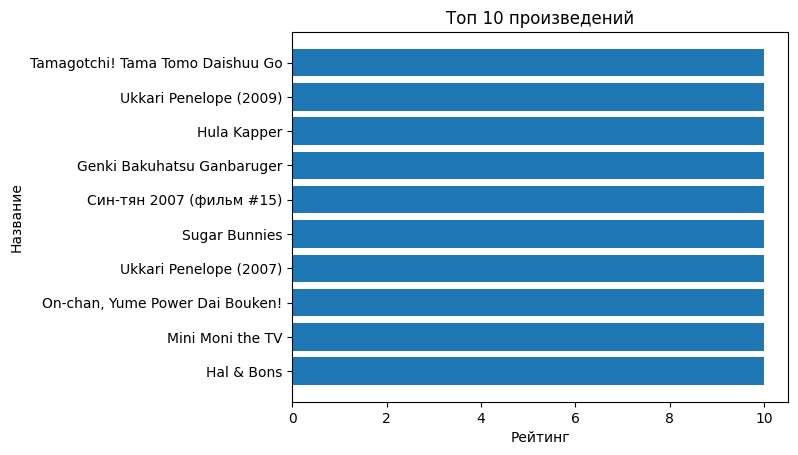

In [61]:
# Horizontal bar chart displaying the top 10 highest-rated titles
top10 = df.sort_values(by='Рейтинг', ascending=False).head(10)

plt.figure()
plt.barh(top10['Название'], top10['Рейтинг'])
plt.title("Топ 10 произведений")
plt.xlabel("Рейтинг")
plt.ylabel("Название")
plt.show()

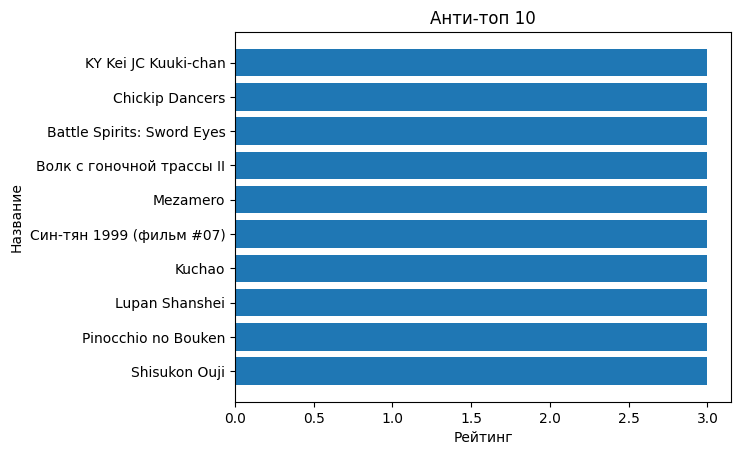

In [62]:
# Horizontal bar chart displaying the 10 lowest-rated titles
bottom10 = df.sort_values(by='Рейтинг').head(10)

plt.figure()
plt.barh(bottom10['Название'], bottom10['Рейтинг'])
plt.title("Анти-топ 10")
plt.xlabel("Рейтинг")
plt.ylabel("Название")
plt.show()

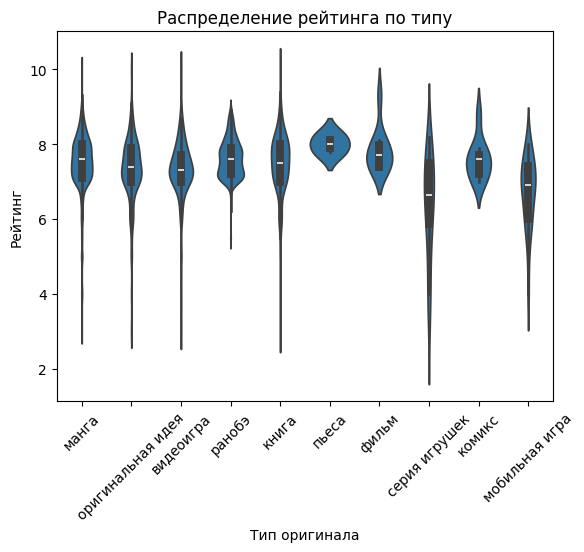

In [63]:
# Violin plot showing the rating distribution across different original content types
plt.figure()
sns.violinplot(x='Тип оригинала', y='Рейтинг', data=df)
plt.title("Распределение рейтинга по типу")
plt.xticks(rotation=45)
plt.show()

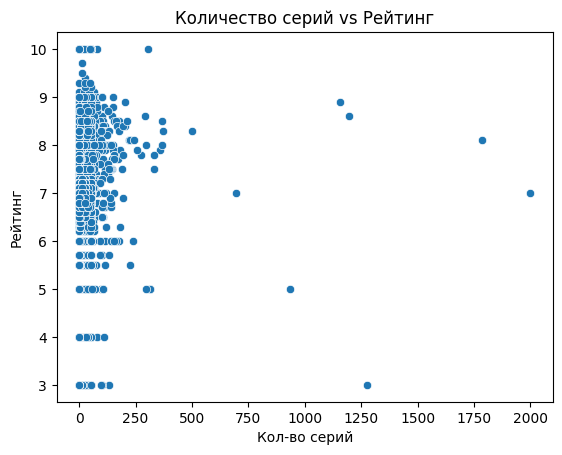

In [64]:
# Scatter plot showing the relationship between number of episodes and rating
plt.figure()
sns.scatterplot(x='Кол-во серий', y='Рейтинг', data=df)
plt.title("Количество серий vs Рейтинг")
plt.xlabel("Кол-во серий")
plt.ylabel("Рейтинг")
plt.show()

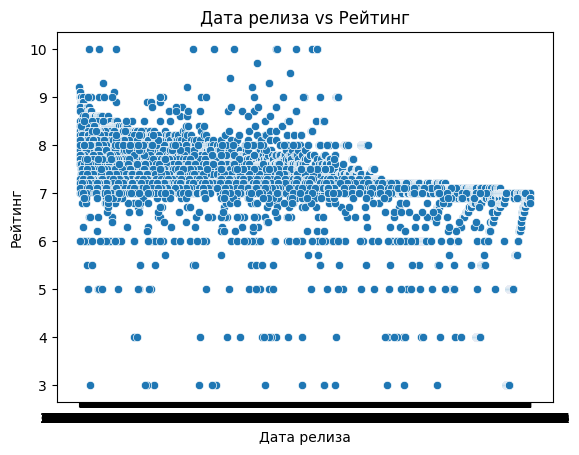

In [65]:
# 4. Scatter (длительность vs рейтинг)
plt.figure()
sns.scatterplot(x='Дата релиза', y='Рейтинг', data=df)
plt.title("Дата релиза vs Рейтинг")
plt.xlabel("Дата релиза")
plt.ylabel("Рейтинг")
plt.show()

Interactive

In [66]:
# Interactive scatter plot exploring the relationship between episode duration and rating, colored by genre
import plotly.express as px

fig = px.scatter(df,
                 x='Длительность (мин)',
                 y='Рейтинг',
                 color='Жанры',
                 title="Интерактивный график")
fig.show()

In [67]:
# Interactive bar chart displaying the top 10 most frequent genres in the dataset
fig2 = px.bar(
    df['Жанры'].value_counts().head(10),
    title="Интерактив: Топ жанров"
)

fig2.show()

In [68]:
# Interactive line chart showing the average rating trend over release years
fig3 = px.line(
    df.groupby('Дата релиза')['Рейтинг'].mean().reset_index(),
    x='Дата релиза',
    y='Рейтинг',
    title="Интерактив: Рейтинг по годам"
)
fig3.show()

Text(0.5, 1.0, 'По годам')

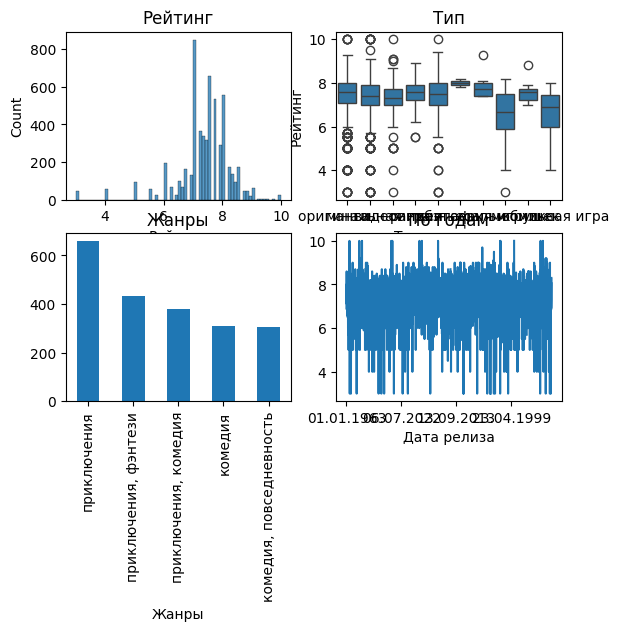

In [69]:
# 6. DASHBOARD
# ================================
fig, axes = plt.subplots(2, 2)

sns.histplot(df['Рейтинг'], ax=axes[0,0])
axes[0,0].set_title("Рейтинг")

sns.boxplot(x='Тип оригинала', y='Рейтинг', data=df, ax=axes[0,1])
axes[0,1].set_title("Тип")

df['Жанры'].value_counts().head(5).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Жанры")

df.groupby('Дата релиза')['Рейтинг'].mean().plot(ax=axes[1,1])
axes[1,1].set_title("По годам")

# ML

In [70]:
from google.colab import files
uploaded = files.upload()

Saving world_art_5000_rows_cleaned-2.csv to world_art_5000_rows_cleaned-2 (3).csv


In [71]:
import pandas as pd
df_3 = pd.read_csv("world_art_5000_rows_cleaned-2.csv")


In [72]:
df_3

,Name,Rating,Number_Episodes,Duration_time,Genres,Release_date,Original_type,Authors,Description,Link,Quality_rating,Movie_Serial,Release_Year,Decade,Duration_hour
0,Крутой учитель Онидзука,9.2,43,25.0,"повседневность, комедия, драма",1999-06-30,манга,Такаги Ватару,"Эйкити Онидзука («22 года, холост», - как он с...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,1999,90's,less than hour
1,Код Гиас: Восставший Лелуш (второй сезон),9.1,25,25.0,"приключения, фантастика, меха, драма",2008-04-06,оригинальная идея,Фукуяма Дзюн,Прошел год с провала Черного Восстания и исчез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,2008,00's,less than hour
2,Стальной алхимик [ТВ-2],9.1,64,25.0,"приключения, фэнтези, драма",2009-04-05,манга,Пак Роми,Нарушив главный запрет Алхимии и попытавшись в...,http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,2009,00's,less than hour
3,Унесённые призраками,9.1,1,125.0,"приключения, фэнтези, драма",2001-07-20,оригинальная идея,Хиираги Руми,Маленькая Тихиро вместе с мамой и папой переез...,http://www.world-art.ru/animation/animation.ph...,Excellent,Movie,2001,00's,more than 2 hours
4,Врата Штейна [ТВ],9.1,24,25.0,"триллер, фантастика, драма",2011-04-06,видеоигра,Мияно Мамору,"Акихабара – интереснейшее место, где обитают с...",http://www.world-art.ru/animation/animation.ph...,Excellent,Serial,2011,10's,less than hour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5624,Gensou Jotan Ellcia,6.9,4,50.0,"приключения, фэнтези",1992-10-23,оригинальная идея,Икура Кадзуэ,Техно-фентези. Одна страна нашла древние техно...,http://www.world-art.ru/animation/animation.ph...,Good,Serial,1992,90's,less than hour
5625,Exper Zenon,6.9,1,60.0,"приключения, фантастика",1991-09-27,оригинальная идея,Мацуно Тайки,"описания ещё нет В В В В ролях: Мацуно Тайки ,...",http://www.world-art.ru/animation/animation.ph...,Good,Movie,1991,90's,less than hour
5626,Дайбастер: Дотянись до неба - 2 (фильм),6.8,1,100.0,"приключения, комедия, фантастика, меха",2006-10-01,оригинальная идея,Unknown,описания ещё нет,http://www.world-art.ru/animation/animation.ph...,Good,Movie,2006,00's,more than hour
5627,Принцесса Минерва,6.8,1,45.0,"приключения, комедия, фэнтези",1995-05-01,видеоигра,Ито Мики,"описания ещё нет В В В В ролях: Ито Мики , Ино...",http://www.world-art.ru/animation/animation.ph...,Good,Movie,1995,90's,less than hour


ML builds a recommendation system that identifies what makes top-rated anime successful. It labels any show with a rating above 8.5 as a 'success', then trains a Random Forest model to detect patterns in genres, formats, and episode lengths that contribute to high scores. The model then assigns a 'prediction_score' to every anime in the dataset, ranking them based on how well they match the characteristics of a top-tier masterpiece.

In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MultiLabelBinarizer

df_3 = pd.read_csv("world_art_5000_rows_cleaned-2.csv")


df_3['user_like'] = (df_3['Rating'] > 8.5).astype(int)

mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df_3['Genres'].str.split(', '))
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

X = pd.concat([
    genres_df,
    pd.get_dummies(df_3['Original_type']),
    df_3[['Number_Episodes', 'Duration_time']]
], axis=1)
y = df_3['user_like']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

df_3['prediction_score'] = model.predict_proba(X)[:, 1]
recommendations = df_3.sort_values(by='prediction_score', ascending=False).head(10)

In [74]:
print(recommendations[['Name', 'Rating', 'prediction_score']])

                                 Name  Rating  prediction_score
78    Нодамэ Кантабиле (третий сезон)     8.7             0.900
133   Нодамэ Кантабиле (второй сезон)     8.6             0.900
136                   Волейбол [ТВ-1]     8.6             0.889
82                    Волейбол [ТВ-2]     8.7             0.889
896                              Саки     8.0             0.889
2329            Второй Мэйджор [ТВ-1]     7.5             0.870
48                      Один на вылет     8.8             0.870
2917            Второй Мэйджор [ТВ-2]     7.4             0.870
1570      Сказки братьев Гримм [ТВ-1]     9.4             0.870
173                 Первый шаг [ТВ-3]     8.6             0.870
